# Adaptive divisive + agglomerative clustering

This notebook exercises `src/adaptive_clustering.py`, a clustering strategy that adapts the number of clusters to the data instead of fixing `k` up front.

**Phase 1 - divisive (split loose clusters):** start from an initial KMeans; any cluster whose *inertia* (compactness score) is above `INERTIA_THRESHOLD` is split into sub-clusters with another KMeans. Each new sub-cluster is checked again and re-split, up to `MAX_SUBDIVISION_ROUNDS` times (default 3). After that a cluster is kept even if still loose.

**Phase 2 - agglomerative (merge redundant clusters):** the closest pair of cluster centroids is merged whenever their distance is below `MERGE_DISTANCE_THRESHOLD`, **unless** the merged cluster's inertia would exceed `INERTIA_THRESHOLD` (the same ceiling used to split). This collapses near-duplicate clusters without creating loose ones.

See the module docstring in `src/adaptive_clustering.py` for the full description, the definition of `inertia_mode`, and the units of each threshold.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from src.column_spec import ColumnSpec
from src.filters import filter_by_nreps, filter_dynamics, filter_by_ffdr
from src.clustering import tslearn_clustering_KMeans, cluster_similarity_per_condition
from src.adaptive_clustering import (
    adaptive_kmeans_clustering,
    adaptive_clustering_report,
    compute_cluster_inertias,
)
from src.plotting_functions import (
    clusters_plot_linear_mutants,
    plot_cluster_scores,
    plot_cluster_assignment_qc,
)

In [2]:
# Clustering historically fills missing values with 0 (= no change from starve).
# This is the established convention for clustering (unlike QC, which keeps NaN).
# NOTE: the .fillna(0) is REQUIRED — without it, a few n:reps==1 sites carry NaN in the FC
# columns, and if MIN_REPS==1 keeps them the initial KMeans (Diagnostic 1) raises
# "Input contains NaN". With MIN_REPS>=2 those sites are filtered out first, hiding the issue.
#
# ⚠ The fill must NOT touch the limma statistics columns. A site limma could not test (detected
# in too few plexes) carries NaN in "..._FFDR_..._omnibus"; fillna(0) would turn that into 0.0,
# i.e. "perfectly significant", and every untested site would sail through the responsiveness
# filter below. So the fill is applied to every column EXCEPT the statistics ones.
#
# The dataset was switched from the 20260714 file to 20260807, which is the one the limma
# results were merged into (see TMT_dataset_preprocessing.ipynb) and the one Clustering.ipynb
# uses. The old load line is kept commented for comparison.
# hme1_mutants = pd.read_csv(
#     "../../Experiment/hme1_mutants_test/Data/Processed/20260505_hTERT_HME1_mutants_test_processed_phosphoPlus_filtered.tsv",
#     sep="\t",
# ).fillna(0)
# hme1_mutants.shape
# hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260714_hTERT_HEM1_2_processed_phPlus.tsv", sep="\t", low_memory=False).fillna(0)
hme1_1 = pd.read_csv("../../Experiment/hme1_1/Data/Processed/20260807_hTERT_HEM1_1_processed_phPlus.tsv", sep="\t", low_memory=False) #.fillna(0)
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv", sep="\t", low_memory=False)
hek_1 = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260807_HEK293T_processed_phPlus.tsv", sep="\t", low_memory=False)


_stat_cols = [c for c in hme1_2.columns
              if any(s in c for s in ("limmaFC", "pvalue", "Fpvalue", "FDR", "FFDR",))]
_fill_cols = [c for c in hme1_2.columns if c not in _stat_cols]
hme1_2[_fill_cols] = hme1_2[_fill_cols].fillna(0)

print(f"{len(_stat_cols)} limma statistics columns left as NaN (not filled with 0)")
hme1_2.shape

76 limma statistics columns left as NaN (not filled with 0)


(50002, 484)

## Parameters

Edit this cell to configure the whole analysis. All downstream cells read from these variables.

In [5]:
df_raw = hme1_2

CELL_LINES   = ["WT"] #, "BRAFS151A", "GAB1Y259A"]
CONDITIONS   = ["_EGF_"] #, "_INS_", "_EGFnINS_"]
DATA_TYPE    = "log2:FC"
EXCLUDE_FULL = True

# Filtering
MIN_REPS = 2
MIN_FC   = 0.5              # |log2FC| threshold (extremes mode)
MAX_FFDR = 0.05             # limma omnibus F-test FDR cutoff (set to None to skip)

# Adaptive clustering knobs
INITIAL_N_CLUSTERS      = 25     # clusters for the first KMeans fit
INERTIA_MODE            = "mean" # 'total' | 'mean' | 'rms' (see module docstring)
N_SUBCLUSTERS           = 2      # pieces per split (binary division)
MAX_SUBDIVISION_ROUNDS  = 3      # max successive splits along any branch
MIN_CLUSTER_SIZE        = 20      # never split clusters smaller than this

# Thresholds - set these after inspecting the diagnostics cells below
INERTIA_THRESHOLD        = 1.30  # (0.3) split above this / reject merges above this
MERGE_DISTANCE_THRESHOLD = 1.50  # (0.4) merge centroids closer than this

CLUSTER_COL = "adaptive_cluster"

# Derived - do not edit
_scan_cols   = ColumnSpec.select(df_raw,
                                 cell_lines=CELL_LINES,
                                 data_type=DATA_TYPE,
                                 conditions=CONDITIONS,
                                 exclude_full=EXCLUDE_FULL,
                                 exclude_replicate_cols=True)
N_DIMS       = len(CELL_LINES) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS
print(f"Columns selected: {len(_scan_cols)}  |  Dimensions: {N_DIMS}  |  Timepoints per condition: {N_TIMEPOINTS}")
print(f"The columns used for the clustering aer: {_scan_cols}")

Columns selected: 6  |  Dimensions: 1  |  Timepoints per condition: 6
The columns used for the clustering aer: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']


## Filtering

Same three steps as `Clustering.ipynb`, in the same order, so both notebooks start from the same
site set and their partitions stay ARI-comparable:

1. **`n:reps >= MIN_REPS`** — drop sites seen in too few plexes.
2. **`|log2FC| >= MIN_FC`** (`mode="extremes"`) — drop flat profiles, so clustering is not
   dominated by noise. Amplitude only; it says nothing about reproducibility.
3. **limma omnibus *F*-test, `FFDR < MAX_FFDR`** — keep only sites whose time course is
   statistically distinguishable from starve, in **any** of the clustered conditions. This is the
   reproducibility criterion the |FC| cutoff cannot give: a 0.6 log2FC seen once is not the same
   evidence as a 0.6 log2FC seen in four plexes. Set `MAX_FFDR = None` to skip the step.

Because this notebook clusters EGF + INS + EGFnINS jointly, step 3 ORs the three per-condition
omnibus columns. `WT_log2:FFDR_ALL_omnibus` — one *F* over all 15 stimulation contrasts — is the
stricter alternative that keeps the error rate exact instead of taking a union of three tests.

Sites limma never tested carry `NaN` and are dropped (`NaN < 0.05` is `False`). The load cell
deliberately leaves the statistics columns un-filled for this reason: `fillna(0)` would make an
untested site look perfectly significant.

In [6]:
df_filtered = filter_by_nreps(df_raw, min_reps=MIN_REPS)
print(f"After n:reps >= {MIN_REPS}:  {df_filtered.shape[0]} sites")

df_filtered = filter_dynamics(df           = df_filtered,
                              cell_lines   = CELL_LINES,
                              conditions   = CONDITIONS,
                              data_type    = DATA_TYPE,
                              threshold    = MIN_FC,
                              mode         = "extremes",
                              exclude_full = EXCLUDE_FULL,  )
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

# ── Responsiveness filter — limma omnibus F-test ─────────────────────────────
# Same filter as in Clustering.ipynb, so both notebooks cluster the same site set and their
# partitions stay ARI-comparable.
# filter_by_ffdr builds "{CellLine}_log2:FFDR_{Condition}_omnibus" (e.g. "WT_log2:FFDR_EGF_omnibus")
# from CELL_LINES x CONDITIONS. MAX_FFDR = None skips the step, so no `if` is needed here.
# combine="any" keeps a site responding in ANY clustered condition. This notebook clusters
# EGF+INS+EGFnINS jointly, so conditions=["_ALL_"] is the stricter alternative — one F over all
# 15 stimulation contrasts instead of an OR over three tests.
# Sites limma did not test carry NaN and are dropped — NaN < 0.05 is False. (This is why the
# load cell does not fillna(0) the statistics columns: 0.0 would pass every cutoff.)
df_filtered = filter_by_ffdr(df           = df_filtered,
                             cell_lines   = CELL_LINES,
                             conditions   = CONDITIONS,
                             max_ffdr     = MAX_FFDR,
                             combine      = "any",
                             verbose      = True,)
print(f"After FFDR < {MAX_FFDR}:      {df_filtered.shape[0]} sites")

After n:reps >= 2:  33719 sites
After |FC| >= 0.5:      8723 sites
FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 7585 of 8723 sites kept (1138 dropped, of which 0 never tested by limma)
After FFDR < 0.05:      7585 sites


## Diagnostic 1 - choose `INERTIA_THRESHOLD`

Fit the initial KMeans and look at the spread of per-cluster inertias. A good `INERTIA_THRESHOLD` sits below the loose clusters (so they get split) but above the tight ones (so they are left alone).

In [7]:
_df_init, _model_init, _X_init = tslearn_clustering_KMeans(df_filtered.copy(),
                                                           data_type                = DATA_TYPE,
                                                           condition_for_clustering = CONDITIONS,
                                                           cell_lines               = CELL_LINES,
                                                           exclude_full             = EXCLUDE_FULL,
                                                           number_of_clusters       = INITIAL_N_CLUSTERS,
                                                           df_dimensions            = N_DIMS,
                                                           time_series_length       = N_TIMEPOINTS,
                                                           cluster_column_name      = "_init", #provisional name for clustering column, used for inertia optimization
                                                           verbose                  = True,
                                                           testing                  = True,
                                                           random_state = 0,
                                                           transpose=False, )

_inertias = compute_cluster_inertias(_X_init, _df_init["_init"].values, mode=INERTIA_MODE) # compute inertias based on the result clustered dataset, no need or re-computing clutsers
print(f"Per-cluster inertia ({INERTIA_MODE}) of the initial {INITIAL_N_CLUSTERS}-cluster fit. Choose your inertia threshold based on these inertias")
for c, v in sorted(_inertias.items(), key=lambda kv: kv[1]):
    print(f"  cluster {c:2d}: {v:.4f}")

Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']

Reshaping dataframe to shape (7585, 1, 6)

The size of the dataset is (7585, 1, 6)
Example:
[[ 0.         -0.03027842  0.38501691  0.72058819  0.26641739  0.46116843]]
Init 1
0.223 --> 0.184 --> 0.180 --> 0.177 --> 0.176 --> 0.174 --> 0.173 --> 0.173 --> 0.172 --> 0.172 --> 0.172 --> 0.172 --> 0.172 --> 0.172 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 
Init 2
0.215 --> 0.183 --> 0.177 --> 0.175 --> 0.174 --> 0.173 --> 0.173 --> 0.172 --> 0.172 --> 0.171 --> 0.171 --> 0.171 --> 0.171 --> 0.170 --> 0.170 --> 0.170 --> 0.170 --> 0.170 --> 0.170 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 --> 0.169 -->

## Diagnostic 2 - choose `MERGE_DISTANCE_THRESHOLD`

Look at the pairwise Euclidean distances between the initial cluster centroids (in the flattened feature space). Set `MERGE_DISTANCE_THRESHOLD` around the smallest distances if some clusters look redundant.

In [8]:
_Xf = _X_init.reshape(_X_init.shape[0], -1) # multivariate numpy matrix
_labels = _df_init["_init"].values # cluster labels for the numpy matrix
_cents = np.vstack([_Xf[_labels == l].mean(axis=0) for l in sorted(np.unique(_labels))]) # compute the centroids (time series mean for sites in the cluster)
_D = np.linalg.norm(_cents[:, None, :] - _cents[None, :, :], axis=2) # Calculation of distances between centroids
_iu = np.triu_indices_from(_D, k=1)
_pair_dists = np.sort(_D[_iu])
print("Smallest centroid-centroid distances:", np.round(_pair_dists[:10], 3))

Smallest centroid-centroid distances: [0.352 0.396 0.401 0.426 0.476 0.478 0.492 0.501 0.501 0.514]


## Run the adaptive clustering

`verbose=True` prints every split and merge decision. `testing=True` also returns the `AdaptiveClusteringResult` object with the full logs, centroids, and per-cluster inertias.

In [9]:
df_clustered, result = adaptive_kmeans_clustering(df_filtered,
                                                  data_type                = DATA_TYPE,
                                                  condition_for_clustering = CONDITIONS,
                                                  cell_lines               = CELL_LINES,
                                                  exclude_full             = EXCLUDE_FULL,
                                                  inertia_threshold        = INERTIA_THRESHOLD,
                                                  merge_distance_threshold = MERGE_DISTANCE_THRESHOLD,
                                                  inertia_mode             = INERTIA_MODE,
                                                  initial_n_clusters       = INITIAL_N_CLUSTERS,
                                                  n_subclusters            = N_SUBCLUSTERS,
                                                  max_subdivision_rounds   = MAX_SUBDIVISION_ROUNDS,
                                                  min_cluster_size         = MIN_CLUSTER_SIZE,
                                                  df_dimensions            = N_DIMS,
                                                  time_series_length       = N_TIMEPOINTS,
                                                  cluster_column_name      = CLUSTER_COL,
                                                  random_state             = 0,
                                                  verbose                  = True,
                                                  testing                  = True,
                                                  transpose = False, )

Column selection (6): ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']

Reshaping dataframe to shape (7585, 1, 6)

Dataset shape: (7585, 1, 6)

[Phase 0] Initial KMeans with 25 clusters

[Phase 1] Divisive splitting (inertia_threshold=1.3, mode=mean, n_subclusters=2, max_rounds=3)
  [depth 0] keep cluster:  1065 sites, inertia=0.0727  (compact)
  [depth 0] keep cluster:   153 sites, inertia=0.3878  (compact)
  [depth 0] keep cluster:    88 sites, inertia=0.3878  (compact)
  [depth 0] keep cluster:   339 sites, inertia=0.1642  (compact)
  [depth 0] keep cluster:   251 sites, inertia=0.1868  (compact)
  [depth 0] keep cluster:   530 sites, inertia=0.1218  (compact)
  [depth 0] keep cluster:    18 sites, inertia=1.1320  (compact)
  [depth 0] SPLIT cluster:    46 sites, inertia=1.5244 -> sub-sizes [24, 22]
  [depth 0] SPLIT cluster:    29 sites, inertia=1.3283 -> sub-sizes [9, 20]
  [depth 0] keep cluster:    8

In [10]:
summary_table = adaptive_clustering_report(result)

Adaptive clustering summary
----------------------------------------
Initial clusters      : 25
Splits performed      : 3
Clusters after split  : 28
Merges accepted       : 18  (rejected by inertia guard: 2)
Final clusters        : 10
Inertia mode          : mean
----------------------------------------
 cluster  n_sites  inertia
       0     5919 0.627855
       1      287 0.931564
       2     1184 0.403039
       3       18 1.132028
       4       83 0.386819
       5       19 2.073936
       6       39 1.234606
       7        9 0.534636
       8       20 1.095589
       9        7 0.748614


### Behavioral note — small high-inertia fragments (keep in mind)

Binary KMeans splitting tends to **peel off small outlier fragments** rather than cut a loose cluster cleanly in half. So a genuinely diffuse region of the data can fragment into several tiny, high-inertia clusters. These fragments then usually **cannot be merged away**, because combining them would push the merged inertia back above `INERTIA_THRESHOLD` (the merge guard rejects it). The result is a scatter of small clusters around the dense, well-resolved ones.

This is faithful to the algorithm as specified — it is not a bug. `MIN_CLUSTER_SIZE` only prevents *splitting* clusters that are already small; it does not stop a split from *producing* a small fragment.

If this becomes a problem, the intended future option is to **reject a split when it would produce a sub-cluster smaller than `MIN_CLUSTER_SIZE`** (so outliers stay attached to their parent cluster). Not implemented yet — noted here so the behavior is expected when reading the split logs and the per-cluster table above.


## Visualise the final clusters

One row per cluster, one column per cell line (grey = individual sites, coloured line = cluster mean).

adaptive Plot not saved


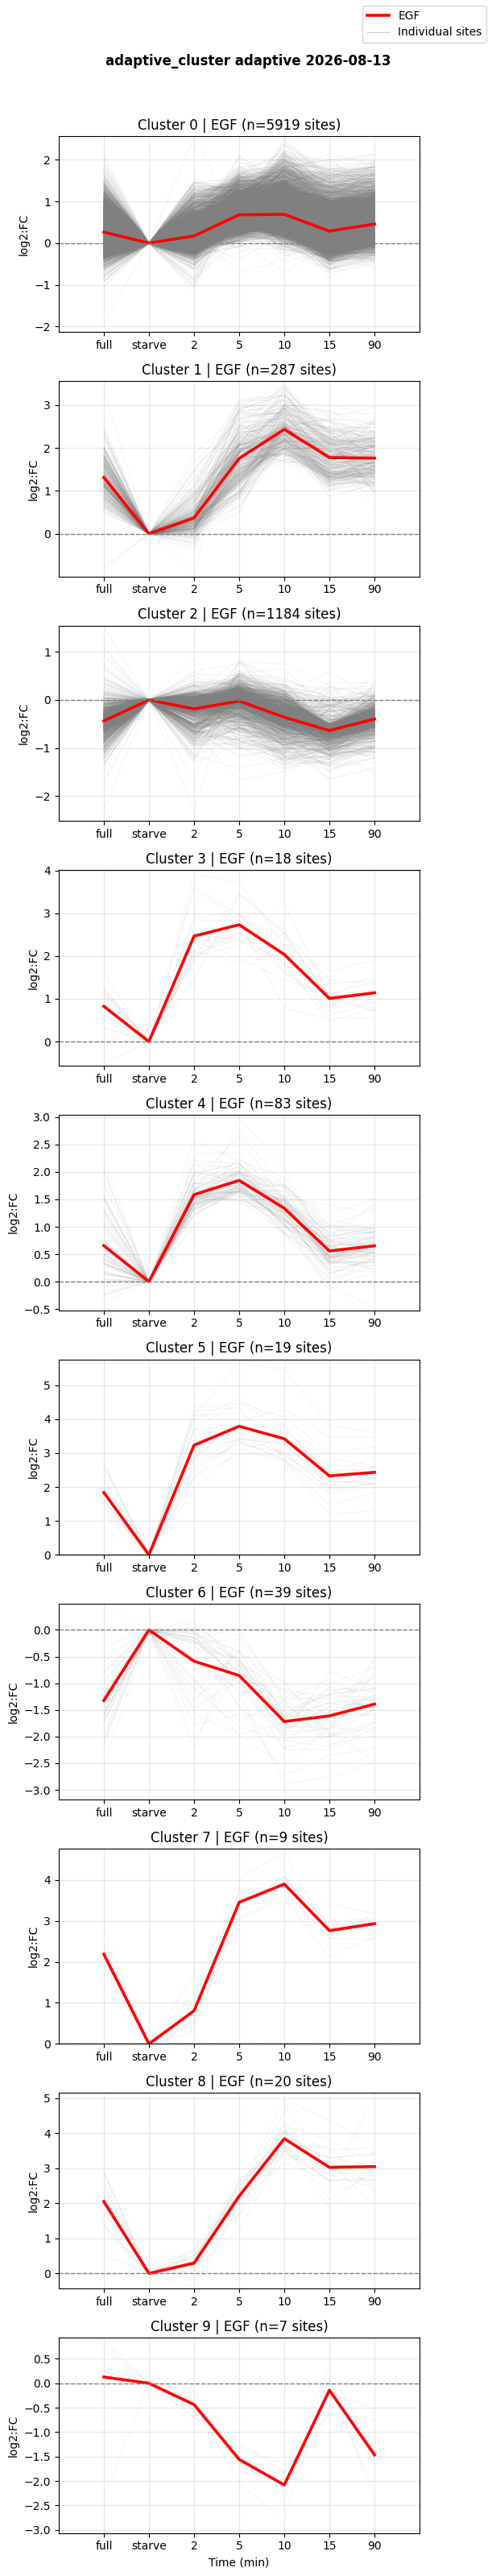

In [11]:
colors = {"_EGF_": "red"} #, "_INS_": "blue", "_EGFnINS_": "fuchsia"} #
# colors = {"WT": "tab:blue", "BRAFS151A": "tab:orange", "GAB1Y259A": "tab:green"}

clusters_plot_linear_mutants(df_clustered,
                             cluster_column = CLUSTER_COL,
                             cluster_name   = "adaptive",
                             data_type      = DATA_TYPE,
                             cell_lines     = CELL_LINES,
                             conditions     = CONDITIONS,
                             colors         = colors,
                             panel_by       = "condition", #cell_line  condition
                             plot_different_data=True, )

## Cluster quality — within-cluster Euclidean dispersion

Lower bars mean tighter (more homogeneous) clusters per condition. Distance is measured point-by-point (Euclidean); since all sites share the same fixed timepoints this is appropriate and much faster than DTW.

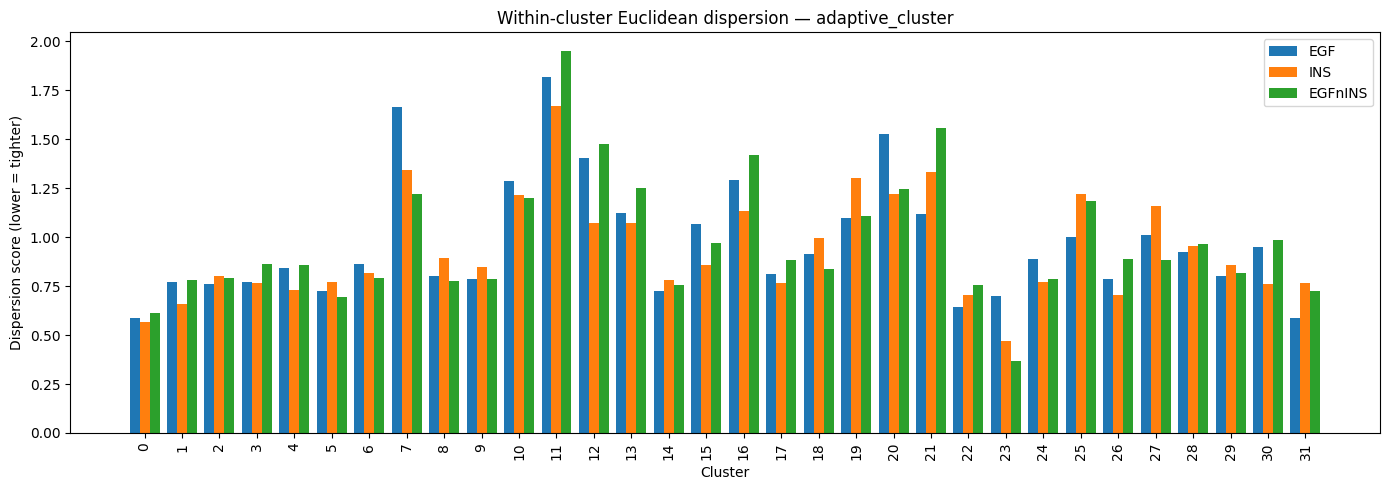

In [25]:
scores = cluster_similarity_per_condition(df                  = df_clustered,
                                          cell_lines          = CELL_LINES,
                                          conditions          = CONDITIONS,
                                          data_type           = DATA_TYPE,
                                          cluster_column_name = CLUSTER_COL,
                                          exclude_full        = EXCLUDE_FULL,
                                          transpose           = True,
                                          metric              = "euclidean",)
fig, ax = plot_cluster_scores(scores,
                              cond_order = [c.strip("_") for c in CONDITIONS],
                              title      = f"Within-cluster Euclidean dispersion — {CLUSTER_COL}",)
plt.show()

## Assignment confidence

Four views of how confidently each site was assigned to its cluster, using the **Euclidean** distance from each site to every final cluster centroid (the adaptive-clustering analogue of the DTW `barycenters` matrix from `tslearn_clustering_KMeans`):

- **Distance-to-centroid heatmap** — rows are sites (sorted by cluster), columns are clusters; the assigned cluster should be the darkest cell in each row.
- **UMAP** — 2-D embedding of the distance-to-centroid matrix coloured by cluster; tight, well-separated blobs indicate clean assignments.
- **Margin histogram** — margin = (2nd-best distance) − (best distance); higher margin = more confident assignment. The orange line marks the 25th percentile (low-confidence sites).
- **Margin per cluster (boxplot)** — reveals which clusters are internally tight vs. ambiguous.

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


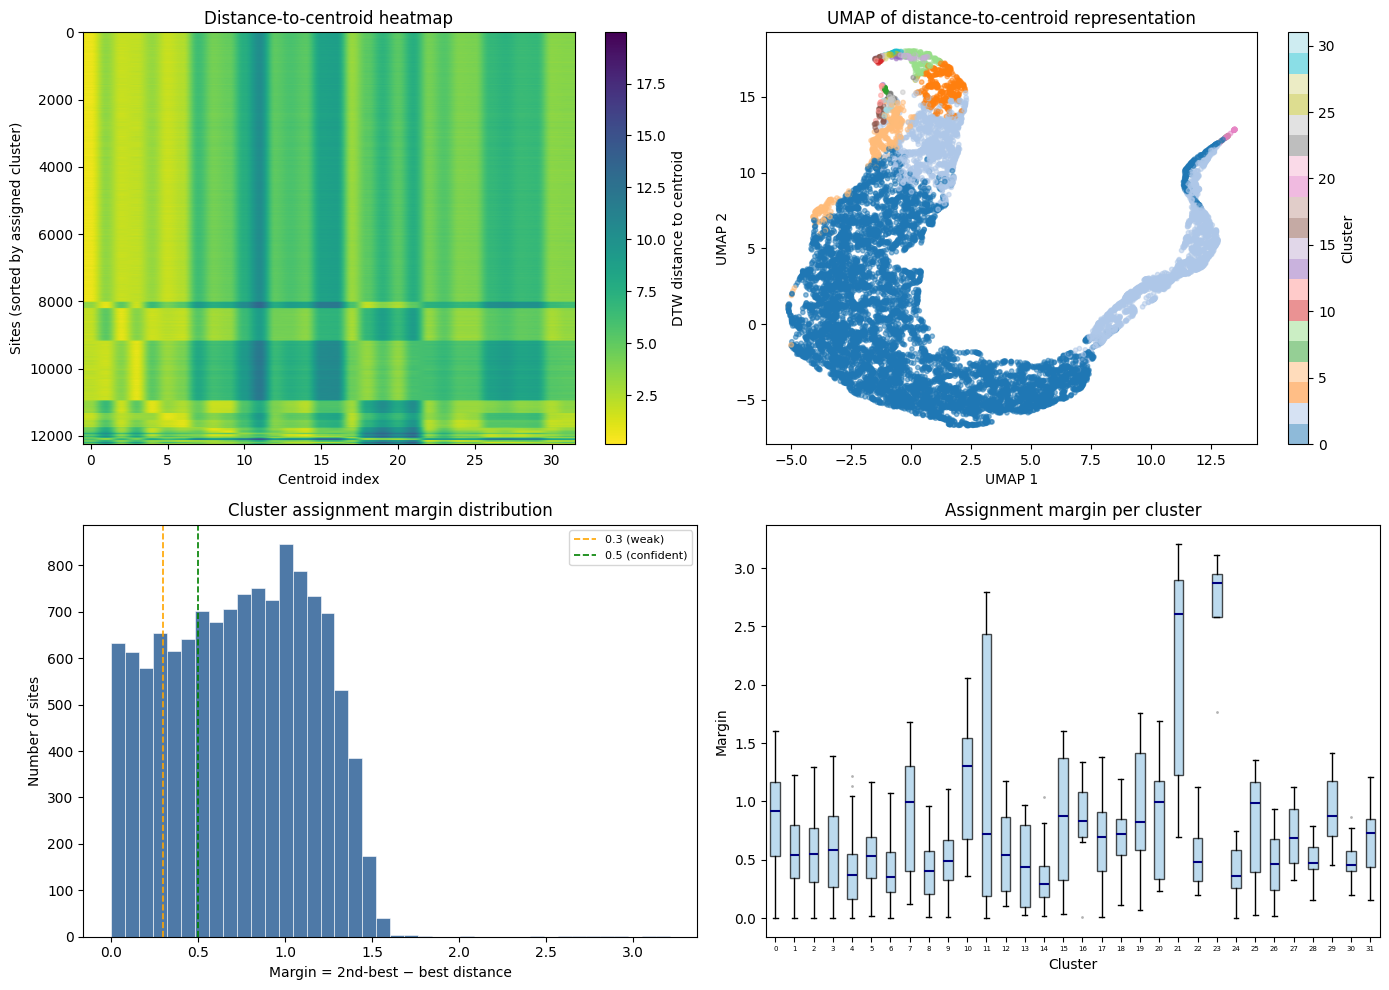

In [26]:
# Euclidean distance from each site to every final cluster centroid.
# result.centroids is (n_clusters x n_features) in the flattened feature space;
# result.X is the reshaped multivariate array. cdist gives the (n_sites x n_clusters)
# distance-to-centroid matrix that plot_cluster_assignment_qc expects.
X_flat = result.X.reshape(result.X.shape[0], -1)
dist_to_centroid = cdist(X_flat, result.centroids, metric="euclidean")

fig, axes = plot_cluster_assignment_qc(dist_to_centroid, result.labels)
plt.show()

## Save (optional)

Never overwrite existing files - use a descriptive suffix / date tag.

In [25]:
# df_clustered.to_csv(
#     "../../data/hTERT_HME1_mutants_test_adaptive_clustered.tsv", sep="\t", index=False)